In [1]:
# Uncomment if running for the first time
!pip install -q lightgbm scipy joblib

Mounted at /content/drive
Loaded focal loss config from losses.py: GAMMA=2.0, ALPHA=0.75
(1000, 42)
dropout_label
0    908
1     92
Name: count, dtype: int64
Observed dropout rate: 9.20%
Composite features present: ['attendance_risk_index', 'socioeconomic_vulnerability_score', 'behavioral_engagement_index']
Training
dropout_label
0    726
1     74
Name: count, dtype: int64

Testing
dropout_label
0    182
1     18
Name: count, dtype: int64
Fitting Variant A - Baseline LightGBM (raw features only)
Fitting Variant B - LightGBM + composite features (ablation control)
Fitting Variant C - E-LightGBM (focal loss + composite features)
Sanity check - predicted probability range (E-LightGBM):
  min=0.0039, max=0.9947, mean=0.0945, std=0.2722
  unique predicted classes at 0.5 threshold: [0 1]


,Model,Accuracy,Precision,Recall,Macro_F1,AUC_ROC,AUC_PR
0,Baseline LightGBM,0.995,1.0,0.944444,0.984344,0.999084,0.992063
1,LightGBM + Composite Features,0.995,1.0,0.944444,0.984344,0.997558,0.982906
2,E-LightGBM (Proposed),0.995,1.0,0.944444,0.984344,0.996642,0.978927


Ablation table saved: focal_loss_ablation_results.csv
Fold 1/25 - Baseline AUC-PR: 1.0000 (0.18s) | E-LightGBM AUC-PR: 0.9835 (0.13s)
Fold 2/25 - Baseline AUC-PR: 0.9861 (0.19s) | E-LightGBM AUC-PR: 0.9815 (0.13s)
Fold 3/25 - Baseline AUC-PR: 0.9971 (0.20s) | E-LightGBM AUC-PR: 0.9971 (0.13s)
Fold 4/25 - Baseline AUC-PR: 0.9777 (0.18s) | E-LightGBM AUC-PR: 0.9701 (0.12s)
Fold 5/25 - Baseline AUC-PR: 0.9049 (0.23s) | E-LightGBM AUC-PR: 0.9082 (0.14s)
Fold 6/25 - Baseline AUC-PR: 1.0000 (0.22s) | E-LightGBM AUC-PR: 1.0000 (0.15s)
Fold 7/25 - Baseline AUC-PR: 0.9657 (0.18s) | E-LightGBM AUC-PR: 0.9735 (0.13s)
Fold 8/25 - Baseline AUC-PR: 0.9757 (0.18s) | E-LightGBM AUC-PR: 0.9739 (0.13s)
Fold 9/25 - Baseline AUC-PR: 0.9791 (0.19s) | E-LightGBM AUC-PR: 0.9922 (0.13s)
Fold 10/25 - Baseline AUC-PR: 1.0000 (0.18s) | E-LightGBM AUC-PR: 1.0000 (0.13s)
Fold 11/25 - Baseline AUC-PR: 1.0000 (0.18s) | E-LightGBM AUC-PR: 1.0000 (0.13s)
Fold 12/25 - Baseline AUC-PR: 1.0000 (0.20s) | E-LightGBM AUC-PR

,Test,Statistic,P_Value,Alpha,Significant,Cohens_d,N_Folds
0,Wilcoxon signed-rank,96.0,0.736632,0.05,False,-0.039622,25


Significance test results saved: focal_loss_significance_test.csv


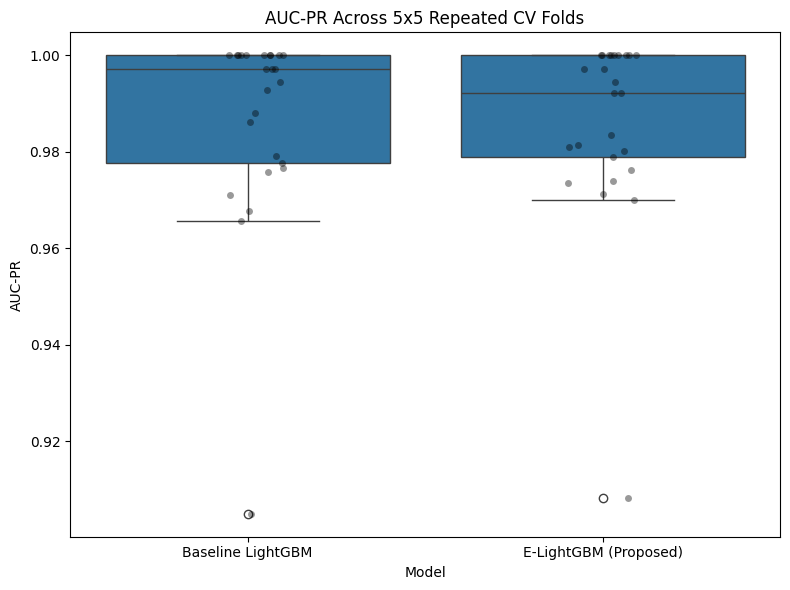

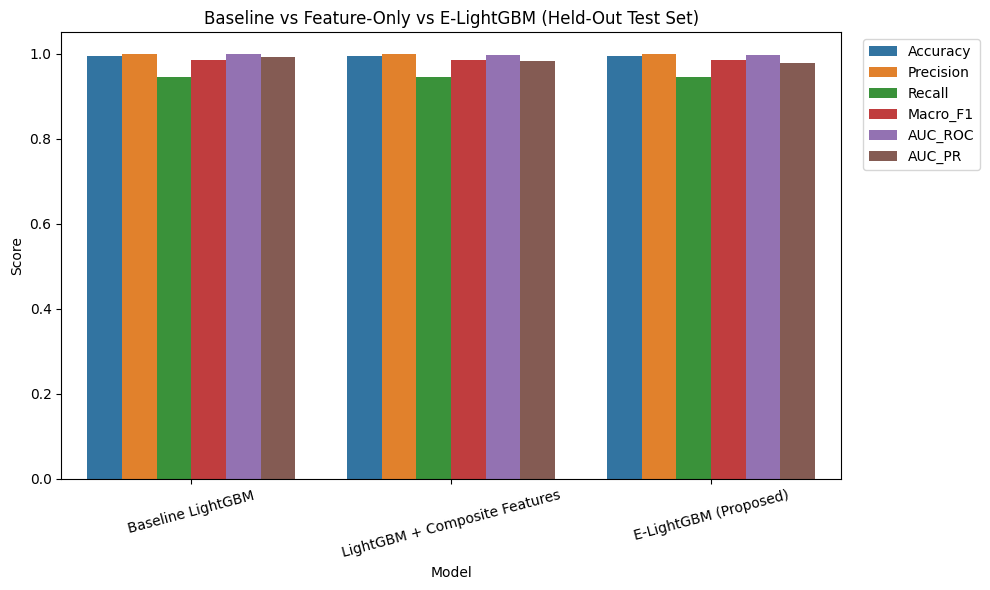

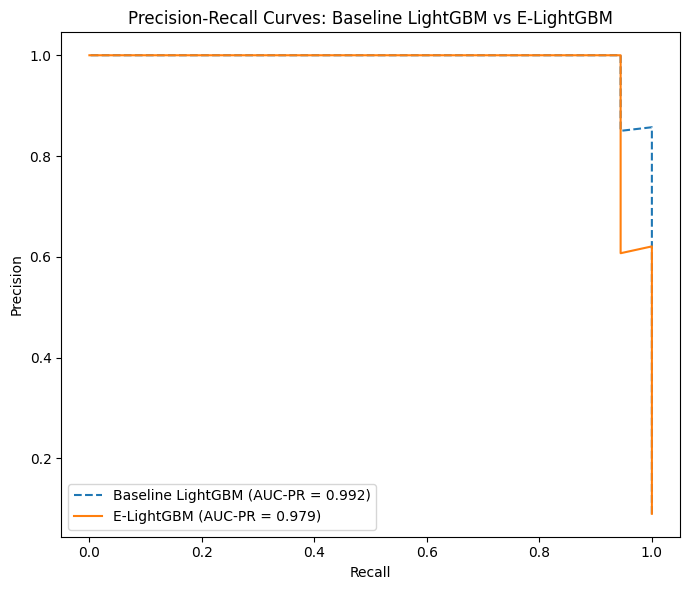

PR curve data saved: pr_curve_data.csv
PR curve figure saved: focal_loss_pr_curve.png
E-LightGBM model, baseline model, and config saved.
NOTEBOOK 6b COMPLETE
Ablation table (3-way): focal_loss_ablation_results.csv
Per-fold CV scores: focal_loss_cv_fold_scores.csv
Significance test: focal_loss_significance_test.csv
Figures: focal_loss_cv_boxplot.png, focal_loss_ablation_comparison.png
Model saved: e_lightgbm_focal_loss_model.pkl

NOTE: predict_proba for E-LightGBM requires the custom sigmoid transform in predict_proba_focal() above - the sklearn wrapper's own .predict_proba() will NOT work correctly with a custom objective. Carry this function into Notebook 7 (SHAP) and Notebook 8 (Final Eval).


In [2]:
# -*- coding: utf-8 -*-
"""Notebook 6b - Focal Loss Engineering (E-LightGBM), v4.ipynb

SETUP REQUIRED BEFORE RUNNING: upload losses.py to
/content/drive/MyDrive/Ghana_Dropout_Project/losses.py first. This
notebook and Notebook 7 both import their focal loss implementation
from that single file, rather than each defining their own copy -
that's what prevents the two notebooks silently drifting out of sync
with different (and possibly buggy) versions of the same function.

Fix applied vs. earlier versions: the custom `objective` function's
parameters were declared as (y_pred, y_true) or, in an earlier draft,
attempted dtrain.get_label() (a native-API convention that doesn't
apply to LGBMClassifier's sklearn-style custom objective, which passes
plain numpy arrays). LightGBM's sklearn API always calls a custom
objective positionally as objective(y_true, y_pred). losses.py declares
the parameters in that correct order.
"""

# ============================================================
# Section 1 - Install Libraries
# ============================================================

# Uncomment if running for the first time
# !pip install -q lightgbm scipy joblib

# ============================================================
# Section 2 - Import Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RepeatedStratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from scipy.stats import wilcoxon

from lightgbm import LGBMClassifier

from google.colab import drive

drive.mount('/content/drive')

# ============================================================
# Section 3 - Project Directories
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/Ghana_Dropout_Project"

MODEL_DIR = f"{PROJECT_DIR}/models"

RESULT_DIR = f"{PROJECT_DIR}/results"

FIGURE_DIR = f"{PROJECT_DIR}/figures"

DATA_DIR = f"{PROJECT_DIR}/data"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

# ============================================================
# Section 3b - Import Shared Loss Functions
# ============================================================
# losses.py must exist at {PROJECT_DIR}/losses.py before running this
# cell. It is the single source of truth for the focal loss objective,
# also imported by Notebook 7 - this guarantees both notebooks always
# use the identical, correctly-argument-ordered implementation.

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

from losses import (
    focal_loss_lgb,
    focal_loss_eval,
    predict_proba_focal,
    GAMMA,
    ALPHA,
    EPSILON,
)

print(f"Loaded focal loss config from losses.py: GAMMA={GAMMA}, ALPHA={ALPHA}")

# ============================================================
# Section 4 - Load the Engineered Dataset (with composite features)
# ============================================================

df = pd.read_csv(f"{PROJECT_DIR}/engineered_data.csv")

print(df.shape)
df.head()

TARGET = "dropout_label"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(y.value_counts())
print("Observed dropout rate: {:.2f}%".format(100 * y.mean()))

composite_features = [
    c for c in [
        "attendance_risk_index",
        "socioeconomic_vulnerability_score",
        "behavioral_engagement_index"
    ]
    if c in X.columns
]

print("Composite features present:", composite_features)

if len(composite_features) < 3:
    print(
        "WARNING: fewer than 3 composite features found in "
        "engineered_data.csv. Re-run Notebook 3 v2 before continuing."
    )

# ============================================================
# Section 5 - Train/Test Split (identical protocol to Notebooks 4/6:
# same random_state, same stratification, no leakage)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training")
print(y_train.value_counts())

print()
print("Testing")
print(y_test.value_counts())

# Section 6 removed: focal_loss_lgb, focal_loss_eval, predict_proba_focal,
# GAMMA, ALPHA, and EPSILON are now imported from losses.py (Section 3b
# above), not defined locally - this is the single source of truth also
# used by Notebook 7.

# ============================================================
# Section 7 - Fixed Hyperparameters (held constant across every
# variant so any performance difference is attributable only to the
# loss function / feature-space changes being tested). These match
# the values already written into Section 2.9 of the Methods section.
# ============================================================

SHARED_PARAMS = dict(
    n_estimators=300,
    num_leaves=31,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

RAW_FEATURE_COLS = [c for c in X.columns if c not in composite_features]

# ============================================================
# Section 8 - Define the Three Model Variants
# ============================================================

# Variant A - Baseline: standard LightGBM, default cross-entropy loss,
# is_unbalance=True, RAW features only (no composites).
def fit_baseline(X_tr, y_tr):
    model = LGBMClassifier(
        objective="binary",
        is_unbalance=True,
        **SHARED_PARAMS
    )
    model.fit(X_tr[RAW_FEATURE_COLS], y_tr)
    return model

# Variant B - Ablation control: standard LightGBM, default cross-entropy
# loss, is_unbalance=True, WITH composite features. Isolates the
# contribution of feature engineering alone.
def fit_ablation_features_only(X_tr, y_tr):
    model = LGBMClassifier(
        objective="binary",
        is_unbalance=True,
        **SHARED_PARAMS
    )
    model.fit(X_tr, y_tr)
    return model

# Variant C - Full E-LightGBM: focal-loss objective, WITH composite
# features. is_unbalance is not used here since the focal loss already
# reweights gradients via alpha - combining both would double-correct.
def fit_focal_lightgbm(X_tr, y_tr):
    model = LGBMClassifier(
        objective=focal_loss_lgb,
        **SHARED_PARAMS
    )
    model.fit(X_tr, y_tr, eval_metric=focal_loss_eval)
    return model

# predict_proba_focal() is imported from losses.py (Section 3b) - not
# redefined here, so Notebook 6b and Notebook 7 always use the same one.


# ============================================================
# Section 9 - Fit All Three Variants on the Full Training Split and
# Evaluate on the Held-Out Test Set
# ============================================================

results = []

fitted_models = {}

print("=" * 60)
print("Fitting Variant A - Baseline LightGBM (raw features only)")
print("=" * 60)

model_a = fit_baseline(X_train, y_train)
y_prob_a = model_a.predict_proba(X_test[RAW_FEATURE_COLS])[:, 1]
y_pred_a = (y_prob_a >= 0.5).astype(int)
fitted_models["Baseline LightGBM"] = model_a

print("=" * 60)
print("Fitting Variant B - LightGBM + composite features (ablation control)")
print("=" * 60)

model_b = fit_ablation_features_only(X_train, y_train)
y_prob_b = model_b.predict_proba(X_test)[:, 1]
y_pred_b = (y_prob_b >= 0.5).astype(int)
fitted_models["LightGBM + Composite Features"] = model_b

print("=" * 60)
print("Fitting Variant C - E-LightGBM (focal loss + composite features)")
print("=" * 60)

model_c = fit_focal_lightgbm(X_train, y_train)
y_prob_c = predict_proba_focal(model_c, X_test)
y_pred_c = (y_prob_c >= 0.5).astype(int)
fitted_models["E-LightGBM (Proposed)"] = model_c

# Sanity check - if this still shows near-0.5 AUC or all-one-class
# predictions, the fix did not resolve the issue and something else
# is going on (check for NaNs in X_train, check that engineered_data.csv
# actually contains the composite features, check LightGBM version).
print("Sanity check - predicted probability range (E-LightGBM):")
print(f"  min={y_prob_c.min():.4f}, max={y_prob_c.max():.4f}, "
      f"mean={y_prob_c.mean():.4f}, std={y_prob_c.std():.4f}")
print(f"  unique predicted classes at 0.5 threshold: {np.unique(y_pred_c)}")

for name, y_pred, y_prob in [
    ("Baseline LightGBM", y_pred_a, y_prob_a),
    ("LightGBM + Composite Features", y_pred_b, y_prob_b),
    ("E-LightGBM (Proposed)", y_pred_c, y_prob_c)
]:
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "Macro_F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "AUC_ROC": roc_auc_score(y_test, y_prob),
        "AUC_PR": average_precision_score(y_test, y_prob)
    })

ablation_table = pd.DataFrame(results)

display(ablation_table)

ablation_table.to_csv(
    f"{RESULT_DIR}/focal_loss_ablation_results.csv",
    index=False
)

print("Ablation table saved: focal_loss_ablation_results.csv")

# ============================================================
# Section 10 - Repeated Stratified Cross-Validation (Baseline vs
# E-LightGBM only, for the significance test)
# ============================================================

N_SPLITS = 5
N_REPEATS = 5

rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42
)

baseline_fold_scores = []
focal_fold_scores = []

baseline_train_times = []
focal_train_times = []

fold_num = 0

for train_idx, val_idx in rskf.split(X, y):

    fold_num += 1

    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    t0 = time.perf_counter()
    baseline_model = fit_baseline(X_tr, y_tr)
    baseline_train_times.append(time.perf_counter() - t0)

    baseline_prob = baseline_model.predict_proba(X_val[RAW_FEATURE_COLS])[:, 1]
    baseline_auc_pr = average_precision_score(y_val, baseline_prob)
    baseline_fold_scores.append(baseline_auc_pr)

    t0 = time.perf_counter()
    focal_model = fit_focal_lightgbm(X_tr, y_tr)
    focal_train_times.append(time.perf_counter() - t0)

    focal_prob = predict_proba_focal(focal_model, X_val)
    focal_auc_pr = average_precision_score(y_val, focal_prob)
    focal_fold_scores.append(focal_auc_pr)

    print(f"Fold {fold_num}/{N_SPLITS * N_REPEATS} - "
          f"Baseline AUC-PR: {baseline_auc_pr:.4f} ({baseline_train_times[-1]:.2f}s) | "
          f"E-LightGBM AUC-PR: {focal_auc_pr:.4f} ({focal_train_times[-1]:.2f}s)")

baseline_fold_scores = np.array(baseline_fold_scores)
focal_fold_scores = np.array(focal_fold_scores)

baseline_train_times = np.array(baseline_train_times)
focal_train_times = np.array(focal_train_times)

print()
print(f"Baseline mean training time/fold: {baseline_train_times.mean():.3f}s "
      f"+/- {baseline_train_times.std():.3f}s")
print(f"E-LightGBM mean training time/fold: {focal_train_times.mean():.3f}s "
      f"+/- {focal_train_times.std():.3f}s")

pct_change = 100 * (focal_train_times.mean() - baseline_train_times.mean()) / baseline_train_times.mean()
print(f"Training overhead: {pct_change:+.1f}%")

training_time_summary = pd.DataFrame([{
    "Model": "Baseline LightGBM",
    "Mean_Train_Time_Sec": baseline_train_times.mean(),
    "SD_Train_Time_Sec": baseline_train_times.std()
}, {
    "Model": "E-LightGBM (Proposed)",
    "Mean_Train_Time_Sec": focal_train_times.mean(),
    "SD_Train_Time_Sec": focal_train_times.std()
}])

training_time_summary.to_csv(
    f"{RESULT_DIR}/focal_loss_training_times.csv",
    index=False
)

print("Training time summary saved: focal_loss_training_times.csv")

cv_fold_results = pd.DataFrame({
    "Fold": range(1, len(baseline_fold_scores) + 1),
    "Baseline_AUC_PR": baseline_fold_scores,
    "ELightGBM_AUC_PR": focal_fold_scores
})

cv_fold_results.to_csv(
    f"{RESULT_DIR}/focal_loss_cv_fold_scores.csv",
    index=False
)

print("Per-fold CV scores saved: focal_loss_cv_fold_scores.csv")




N_SPLITS = 5
N_REPEATS = 5

rskf_table2 = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42
)

baseline_scores = []
features_only_scores = []
focal_scores = []

features_only_times = []

fold_num = 0

for train_idx, val_idx in rskf_table2.split(X, y):
    fold_num += 1

    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Variant A — Baseline (raw features only, cross-entropy)
    baseline_model = fit_baseline(X_tr, y_tr)
    baseline_prob = baseline_model.predict_proba(X_val[RAW_FEATURE_COLS])[:, 1]
    baseline_scores.append(average_precision_score(y_val, baseline_prob))

    # Variant B — LightGBM + composite features, still cross-entropy
    # (this is the arm that was missing a repeated-CV number)
    t0 = time.perf_counter()
    features_only_model = fit_ablation_features_only(X_tr, y_tr)
    features_only_times.append(time.perf_counter() - t0)
    features_only_prob = features_only_model.predict_proba(X_val)[:, 1]
    features_only_scores.append(average_precision_score(y_val, features_only_prob))

    # Variant C — full E-LightGBM (composite features + focal loss)
    focal_model = fit_focal_lightgbm(X_tr, y_tr)
    focal_prob = predict_proba_focal(focal_model, X_val)
    focal_scores.append(average_precision_score(y_val, focal_prob))

    print(f"Fold {fold_num}/{N_SPLITS * N_REPEATS} - "
          f"Baseline: {baseline_scores[-1]:.4f} | "
          f"+Features: {features_only_scores[-1]:.4f} | "
          f"E-LightGBM: {focal_scores[-1]:.4f}")

baseline_scores = np.array(baseline_scores)
features_only_scores = np.array(features_only_scores)
focal_scores = np.array(focal_scores)

table2 = pd.DataFrame([
    {
        "Model": "Baseline LightGBM",
        "Mean_AUC_PR": baseline_scores.mean(),
        "SD_AUC_PR": baseline_scores.std(ddof=1),
        "N_Folds": len(baseline_scores),
    },
    {
        "Model": "LightGBM + Composite Features",
        "Mean_AUC_PR": features_only_scores.mean(),
        "SD_AUC_PR": features_only_scores.std(ddof=1),
        "N_Folds": len(features_only_scores),
    },
    {
        "Model": "E-LightGBM (Proposed)",
        "Mean_AUC_PR": focal_scores.mean(),
        "SD_AUC_PR": focal_scores.std(ddof=1),
        "N_Folds": len(focal_scores),
    },
]).round(4)

print(table2)

table2.to_csv(f"{RESULT_DIR}/table2_three_way_ablation_cv.csv", index=False)
print("Saved: results/table2_three_way_ablation_cv.csv")

# Also save the raw per-fold scores for all three variants, in case
# the significance test in Section 11 needs to be extended to the
# features-only arm as well.
per_fold = pd.DataFrame({
    "Fold": range(1, len(baseline_scores) + 1),
    "Baseline_AUC_PR": baseline_scores,
    "FeaturesOnly_AUC_PR": features_only_scores,
    "ELightGBM_AUC_PR": focal_scores,
})
per_fold.to_csv(f"{RESULT_DIR}/table2_three_way_cv_fold_scores.csv", index=False)
print("Saved: results/table2_three_way_cv_fold_scores.csv")

# ============================================================
# Section 11 - Statistical Significance (Wilcoxon signed-rank + Cohen's d)
# ============================================================

wilcoxon_stat, wilcoxon_p = wilcoxon(focal_fold_scores, baseline_fold_scores)

diff = focal_fold_scores - baseline_fold_scores

pooled_std = np.sqrt(
    (baseline_fold_scores.std(ddof=1) ** 2 + focal_fold_scores.std(ddof=1) ** 2) / 2
)

cohens_d = diff.mean() / pooled_std if pooled_std > 0 else float("nan")

print(f"Wilcoxon signed-rank statistic: {wilcoxon_stat:.4f}")
print(f"Wilcoxon p-value: {wilcoxon_p:.6f}")
print(f"Cohen's d (paired, pooled SD): {cohens_d:.4f}")

significance_summary = pd.DataFrame([{
    "Test": "Wilcoxon signed-rank",
    "Statistic": wilcoxon_stat,
    "P_Value": wilcoxon_p,
    "Alpha": 0.05,
    "Significant": bool(wilcoxon_p < 0.05),
    "Cohens_d": cohens_d,
    "N_Folds": len(baseline_fold_scores)
}])

display(significance_summary)

significance_summary.to_csv(
    f"{RESULT_DIR}/focal_loss_significance_test.csv",
    index=False
)

print("Significance test results saved: focal_loss_significance_test.csv")

# ============================================================
# Section 12 - Visualization
# ============================================================

plt.figure(figsize=(8, 6))

box_data = pd.DataFrame({
    "AUC-PR": np.concatenate([baseline_fold_scores, focal_fold_scores]),
    "Model": (
        ["Baseline LightGBM"] * len(baseline_fold_scores)
        + ["E-LightGBM (Proposed)"] * len(focal_fold_scores)
    )
})

sns.boxplot(data=box_data, x="Model", y="AUC-PR")
sns.stripplot(data=box_data, x="Model", y="AUC-PR", color="black", alpha=0.4, jitter=True)

plt.title(f"AUC-PR Across {N_SPLITS}x{N_REPEATS} Repeated CV Folds")
plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/focal_loss_cv_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(10, 6))

melted = ablation_table.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "Macro_F1", "AUC_ROC", "AUC_PR"],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(data=melted, x="Model", y="Score", hue="Metric")

plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.title("Baseline vs Feature-Only vs E-LightGBM (Held-Out Test Set)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/focal_loss_ablation_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Precision-Recall curve: Baseline LightGBM vs E-LightGBM on the
# held-out test set (uses y_prob_a / y_prob_c already computed in
# Section 9 - not a re-fit, just re-using those predictions).
# ------------------------------------------------------------

from sklearn.metrics import precision_recall_curve

baseline_precision, baseline_recall, _ = precision_recall_curve(y_test, y_prob_a)
focal_precision, focal_recall, _ = precision_recall_curve(y_test, y_prob_c)

# Save raw curve arrays so the figure can be rebuilt/restyled later
# without re-running the models.
pr_curve_baseline_df = pd.DataFrame({
    "Recall": baseline_recall,
    "Precision": baseline_precision,
    "Model": "Baseline LightGBM"
})

pr_curve_focal_df = pd.DataFrame({
    "Recall": focal_recall,
    "Precision": focal_precision,
    "Model": "E-LightGBM (Proposed)"
})

pr_curve_data = pd.concat([pr_curve_baseline_df, pr_curve_focal_df], ignore_index=True)

pr_curve_data.to_csv(
    f"{RESULT_DIR}/pr_curve_data.csv",
    index=False
)

baseline_auc_pr_test = average_precision_score(y_test, y_prob_a)
focal_auc_pr_test = average_precision_score(y_test, y_prob_c)

plt.figure(figsize=(7, 6))

plt.plot(
    baseline_recall, baseline_precision,
    linestyle="--", label=f"Baseline LightGBM (AUC-PR = {baseline_auc_pr_test:.3f})"
)

plt.plot(
    focal_recall, focal_precision,
    linestyle="-", label=f"E-LightGBM (AUC-PR = {focal_auc_pr_test:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves: Baseline LightGBM vs E-LightGBM")
plt.legend(loc="lower left")
plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/focal_loss_pr_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("PR curve data saved: pr_curve_data.csv")
print("PR curve figure saved: focal_loss_pr_curve.png")

# ============================================================
# Section 13 - Save the Final E-LightGBM Model
# ============================================================

joblib.dump(
    model_c,
    f"{MODEL_DIR}/e_lightgbm_focal_loss_model.pkl"
)

joblib.dump(
    model_a,
    f"{MODEL_DIR}/baseline_lightgbm_model.pkl"
)

joblib.dump(
    {"gamma": GAMMA, "alpha": ALPHA, "shared_params": SHARED_PARAMS,
     "raw_feature_cols": RAW_FEATURE_COLS,
     "composite_features": composite_features},
    f"{MODEL_DIR}/e_lightgbm_config.pkl"
)

X_test.to_csv(f"{DATA_DIR}/X_test_focal.csv", index=False)
y_test.to_csv(f"{DATA_DIR}/y_test_focal.csv", index=False)

print("E-LightGBM model, baseline model, and config saved.")

# ============================================================
# Section 14 - Notebook Summary
# ============================================================

print("=" * 60)
print("NOTEBOOK 6b COMPLETE")
print("=" * 60)

print("Ablation table (3-way): focal_loss_ablation_results.csv")
print("Per-fold CV scores: focal_loss_cv_fold_scores.csv")
print("Significance test: focal_loss_significance_test.csv")
print("Figures: focal_loss_cv_boxplot.png, focal_loss_ablation_comparison.png")
print("Model saved: e_lightgbm_focal_loss_model.pkl")
print()
print("NOTE: predict_proba for E-LightGBM requires the custom sigmoid "
      "transform in predict_proba_focal() above - the sklearn wrapper's "
      "own .predict_proba() will NOT work correctly with a custom "
      "objective. Carry this function into Notebook 7 (SHAP) and "
      "Notebook 8 (Final Eval).")